In [76]:
import numpy as np 
import re
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, roc_curve, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

# EXER 1
### 1.	Load and inspect the Women’s Clothing E-Commerce Reviews dataset. Identify its shape, columns, first five records, and null values.

In [3]:
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df.shape

(23486, 11)

In [5]:
df.columns.tolist()

['Unnamed: 0',
 'Clothing ID',
 'Age',
 'Title',
 'Review Text',
 'Rating',
 'Recommended IND',
 'Positive Feedback Count',
 'Division Name',
 'Department Name',
 'Class Name']

In [6]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [9]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

### 1.	Load and inspect the Women’s Clothing E-Commerce Reviews dataset. Identify its shape, columns, first five records, and null values

In [10]:
df_clean = df.dropna()

product_counts = df_clean['Clothing ID'].value_counts()
valid_products = product_counts[product_counts >= 5].index

df_processed = df_clean[df_clean['Clothing ID'].isin(valid_products)].reset_index(drop=True)

print("Processed Dataset Shape:", df_processed.shape)

Processed Dataset Shape: (18401, 11)


In [12]:
df_processed.isnull().sum()

Unnamed: 0                 0
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

### 3.	Clean Review Text by expanding contractions, converting uppercase characters to lowercase, and removing punctuation and special characters

In [14]:
def clean_review_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df_processed['Cleaned Review Text'] = df_processed['Review Text'].apply(clean_review_text)

# Preview the results
print(df_processed[['Review Text', 'Cleaned Review Text']].head())

                                         Review Text  \
0  I had such high hopes for this dress and reall...   
1  I love, love, love this jumpsuit. it's fun, fl...   
2  I love tracy reese dresses, but this one is no...   
3  I aded this in my basket at hte last mintue to...   
4  I ordered this in carbon for store pick up, an...   

                                 Cleaned Review Text  
0  i had such high hopes for this dress and reall...  
1  i love love love this jumpsuit its fun flirty ...  
2  i love tracy reese dresses but this one is not...  
3  i aded this in my basket at hte last mintue to...  
4  i ordered this in carbon for store pick up and...  


### 4.	Separate the independent and dependent variables and split the dataset into training and testing sets in the ratio 80:20

In [25]:
X = df_processed['Cleaned Review Text']
y = df_processed['Recommended IND']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (14720,)
Testing Features Shape: (3681,)
Training Target Shape: (14720,)
Testing Target Shape: (3681,)


### 5.	Convert the cleaned review text into numerical features using TF-IDF Vectorization

In [26]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (14720, 14919)
Testing TF-IDF Shape: (3681, 14919)


### 6.	Apply the Multinomial Naïve Bayes Classification Algorithm to predict whether an item is recommended

In [28]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred = nb_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.8188

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       670
           1       0.82      1.00      0.90      3011

    accuracy                           0.82      3681
   macro avg       0.91      0.50      0.45      3681
weighted avg       0.85      0.82      0.74      3681

Confusion Matrix:
[[   3  667]
 [   0 3011]]


### 7.	Evaluate and tabulate the performance of the Naïve Bayes classifier using accuracy, precision, recall, F1-score, and confusion matrix

In [29]:
y_pred = nb_model.predict(X_test_tfidf)

report_dict = classification_report(y_test, y_pred, output_dict=True)

metrics_df = pd.DataFrame(report_dict).transpose()

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}\n")

print("Performance Metrics Table:")
print(metrics_df)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

Overall Accuracy: 0.8188

Performance Metrics Table:
              precision    recall  f1-score      support
0              1.000000  0.004478  0.008915   670.000000
1              0.818651  1.000000  0.900284  3011.000000
accuracy       0.818799  0.818799  0.818799     0.818799
macro avg      0.909326  0.502239  0.454600  3681.000000
weighted avg   0.851660  0.818799  0.738041  3681.000000

Confusion Matrix Breakdown:
True Negatives (TN): 3
False Positives (FP): 667
False Negatives (FN): 0
True Positives (TP): 3011


### 8.	Use the trained Naïve Bayes model to predict whether an item is recommended for a new customer review. 

In [30]:
new_review = ["This dress is absolutely stunning and fits perfectly! I love it so much."]

cleaned_new_review = [clean_review_text(review) for review in new_review]

new_review_tfidf = vectorizer.transform(cleaned_new_review)

prediction = nb_model.predict(new_review_tfidf)
prediction_proba = nb_model.predict_proba(new_review_tfidf)

status = "Recommended (1)" if prediction[0] == 1 else "Not Recommended (0)"
confidence = prediction_proba[0][prediction[0]]

print(f"Review Text: '{new_review[0]}'")
print(f"Prediction:  {status}")
print(f"Confidence:  {confidence:.4f}")

Review Text: 'This dress is absolutely stunning and fits perfectly! I love it so much.'
Prediction:  Recommended (1)
Confidence:  0.9886


### 9.	Test the trained classifier with positive and negative sample reviews and interpret the predictions

In [38]:
sample_reviews = [
    "This is the best purchase I have ever made! The fabric is soft and the fit is amazing.",
    "Terrible quality. The stitching came undone after just one wash and it looks cheap.",
    "It is okay, nothing special, but fits well enough for daily wear.",
    "Awful fit and completely unflattering. I am returning this immediately.",
    "Very disappointed. The color bled all over my other clothes in the laundry.",
]


for i, review in enumerate(sample_reviews, 1):
    cleaned = clean_review_text(review)
    
    vectorized = vectorizer.transform([cleaned])
    
    pred = nb_model.predict(vectorized)[0]
    proba = nb_model.predict_proba(vectorized)[0]
    
    status = "Recommended (1)" if pred == 1 else "Not Recommended (0)"
    confidence = proba[pred]
    
    print(f"Test Review {i}: '{review}'")
    print(f"Prediction:  {status}")
    print(f"Confidence:  {confidence:.4f}\n")

Test Review 1: 'This is the best purchase I have ever made! The fabric is soft and the fit is amazing.'
Prediction:  Recommended (1)
Confidence:  0.9837

Test Review 2: 'Terrible quality. The stitching came undone after just one wash and it looks cheap.'
Prediction:  Recommended (1)
Confidence:  0.5943

Test Review 3: 'It is okay, nothing special, but fits well enough for daily wear.'
Prediction:  Recommended (1)
Confidence:  0.8993

Test Review 4: 'Awful fit and completely unflattering. I am returning this immediately.'
Prediction:  Not Recommended (0)
Confidence:  0.7216

Test Review 5: 'Very disappointed. The color bled all over my other clothes in the laundry.'
Prediction:  Recommended (1)
Confidence:  0.5468



- Review 1: Correctly predicted positive due to strong positive keywords like "best" and "amazing".

- Review 2: False positive with low confidence, showing the model detected negative sentiment but failed to override its positive bias.

- Review 3: Classified as positive due to the dataset's heavy positive class skew, despite neutral phrasing.

- Review 4: Correctly predicted negative because terms like "awful" and "unflattering" were strong enough to break the model's bias.

- Review 5: False positive with near-random confidence, highlighting the model's struggle to catch complaints about product damage.

# EXER 2

### 1.	Load and explore the Cancer dataset. Display its structure and identify missing values.

In [41]:
df2 = pd.read_csv("cancer.csv")
df2.shape

(51, 75)

In [46]:
df2.head()

,State,Total.Rate,Total.Number,Total.Population,Rates.Age.< 18,Rates.Age.18-45,Rates.Age.45-64,Rates.Age.> 64,Rates.Age and Sex.Female.< 18,Rates.Age and Sex.Male.< 18,...,Types.Lung.Age and Sex.Male.45 - 64,Types.Lung.Age and Sex.Female.> 64,Types.Lung.Age and Sex.Male.> 64,Types.Lung.Race.White,Types.Lung.Race.White non-Hispanic,Types.Lung.Race.Black,Types.Lung.Race.Black non-Hispanic,Types.Lung.Race.Asian,Types.Lung.Race.Indigenous,Types.Lung.Race.Hispanic
0,Alabama,214.2,71529.0,33387205.0,2.0,18.5,244.7,1017.8,2.0,2.1,...,102.9,221.7,457.4,59.9,60.4,52.6,52.8,23.0,22.9,14.8
1,Alaska,128.1,6361.0,4966180.0,1.7,11.8,170.9,965.2,0.0,0.0,...,50.3,268.3,335.0,48.7,49.5,45.6,47.9,33.0,74.4,0.0
2,Arizona,165.6,74286.0,44845598.0,2.5,13.6,173.6,840.2,2.6,2.5,...,47.0,191.9,275.8,39.5,42.2,38.2,40.4,21.3,11.1,21.6
3,Arkansas,223.9,45627.0,20382448.0,2.3,17.6,250.1,1048.3,2.6,2.0,...,106.5,248.7,484.7,63.4,64.2,62.9,63.0,18.1,16.2,14.6
4,California,150.9,393980.0,261135696.0,2.6,13.7,163.7,902.4,2.4,2.8,...,36.8,192.5,269.0,37.2,42.6,46.5,48.6,25.8,18.4,18.3


In [47]:
df2.info

<bound method DataFrame.info of                    State  Total.Rate  Total.Number  Total.Population  \
0                Alabama       214.2       71529.0        33387205.0   
1                 Alaska       128.1        6361.0         4966180.0   
2                Arizona       165.6       74286.0        44845598.0   
3               Arkansas       223.9       45627.0        20382448.0   
4             California       150.9      393980.0       261135696.0   
5               Colorado       139.0       49035.0        35267734.0   
6            Connecticut       190.5       47567.0        24975889.0   
7               Delaware       210.2       13233.0         6295263.0   
8   District of Columbia       182.1        7730.0         4245359.0   
9                Florida       219.2      289905.0       132277071.0   
10               Georgia       159.4      108222.0        67890652.0   
11                Hawaii       166.0       15812.0         9526083.0   
12                 Idaho       1

In [48]:
df2.isnull().sum()

State                                 0
Total.Rate                            0
Total.Number                          0
Total.Population                      0
Rates.Age.< 18                        0
                                     ..
Types.Lung.Race.Black                 0
Types.Lung.Race.Black non-Hispanic    0
Types.Lung.Race.Asian                 0
Types.Lung.Race.Indigenous            0
Types.Lung.Race.Hispanic              0
Length: 75, dtype: int64

### 2. Calculate correlation coefficients and identify highly correlated features. 

In [49]:
numeric_df = df2.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

threshold = 0.85
corr_abs = corr_matrix.abs()
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

high_corr = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.loc[row, col] > threshold
]

high_corr_df = pd.DataFrame(high_corr, columns=['Feature 1', 'Feature 2', 'Correlation'])
print(high_corr_df.sort_values(by='Correlation', ascending=False).head(10))

                                        Feature 1  \
63       Types.Colorectal.Race.Black non-Hispanic   
43           Types.Breast.Race.Black non-Hispanic   
35     Rates.Race and Sex.Male.Black non-Hispanic   
19   Rates.Race and Sex.Female.Black non-Hispanic   
28     Rates.Race and Sex.Male.White non-Hispanic   
6                  Rates.Age and Sex.Male.45 - 64   
54       Types.Colorectal.Race.White non-Hispanic   
113            Types.Lung.Race.White non-Hispanic   
11                  Rates.Race.White non-Hispanic   
4                Rates.Age and Sex.Female.45 - 64   

                           Feature 2  Correlation  
63       Types.Colorectal.Race.Black     0.997633  
43           Types.Breast.Race.Black     0.997587  
35     Rates.Race and Sex.Male.Black     0.996777  
19   Rates.Race and Sex.Female.Black     0.996322  
28     Rates.Race and Sex.Male.White     0.993139  
6                    Rates.Age.45-64     0.992498  
54       Types.Colorectal.Race.White     0.992186  


### 3.	 Remove highly correlated features using a suitable correlation threshold.

In [50]:
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > threshold)]

df_reduced = numeric_df.drop(columns=to_drop)

print(f"Dropped {len(to_drop)} highly correlated features.")
print(f"Remaining feature count: {df_reduced.shape[1]}")

Dropped 40 highly correlated features.
Remaining feature count: 34


### 4.	Convert a continuous age-based cancer-rate variable into categorical bins

In [51]:
# Choose a continuous age-rate column, for example: 'Rates.Age.45-64'
target_column = 'Rates.Age.45-64'

bin_edges = [0, 150, 200, 300] 
bin_labels = ['Low', 'Moderate', 'High']

df2['Age_Rate_Category'] = pd.cut(
    df2[target_column], 
    bins=bin_edges, 
    labels=bin_labels, 
    include_lowest=True
)

print(df2['Age_Rate_Category'].value_counts())

Moderate    29
High        20
Low          2
Name: Age_Rate_Category, dtype: int64


### 5.	Apply PCA to reduce the dimensionality of the selected features while retaining at least 95% of variance. 

In [54]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_reduced)

pca = PCA(n_components=0.95)
pca_transformed = pca.fit_transform(scaled_data)

print(f"Original feature count: {df_reduced.shape[1]}")
print(f"Reduced feature count (95% variance): {pca_transformed.shape[1]}")

Original feature count: 34
Reduced feature count (95% variance): 15


### 6.	Create a binary target variable based on whether Total.Rate is above the third quartile.

In [55]:
q3 = df2['Total.Rate'].quantile(0.75)

df2['High_Total_Rate'] = (df2['Total.Rate'] > q3).astype(int)

print(df2['High_Total_Rate'].value_counts())

0    38
1    13
Name: High_Total_Rate, dtype: int64


### 7.	Select the seven specified features and split the dataset into training and testing sets using an 80:20 ratio.

In [69]:
selected_features = [
    'Total.Number', 
    'Total.Population', 
    'Rates.Age.< 18', 
    'Rates.Age.18-45', 
    'Rates.Age.45-64', 
    'Rates.Age.> 64', 
    'Total.Rate'
]

X = df2[selected_features]
y = df2['High_Total_Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=27, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (40, 7)
Testing set shape: (11, 7)


### 8.	Train GaussianNB, MultinomialNB, and BernoulliNB classifiers using the selected features. 

In [70]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

gnb.fit(X_train, y_train)
mnb.fit(X_train, y_train)
bnb.fit(X_train, y_train)

BernoulliNB()

### 9.	Compare the three classifiers using accuracy, precision, recall, F1-score, and ROC-AUC.

In [71]:
models = {
    'GaussianNB': gnb, 
    'MultinomialNB': mnb, 
    'BernoulliNB': bnb
}

evaluation_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] 
    
    evaluation_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

metrics_df = pd.DataFrame(evaluation_results)
print(metrics_df.to_string(index=False))

        Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
   GaussianNB  0.545455       0.00     0.0  0.000000   0.1250
MultinomialNB  0.909091       0.75     1.0  0.857143   0.9375
  BernoulliNB  0.727273       0.00     0.0  0.000000   0.5000


### 10.	Generate and interpret the confusion matrices of the three Naïve Bayes models. 

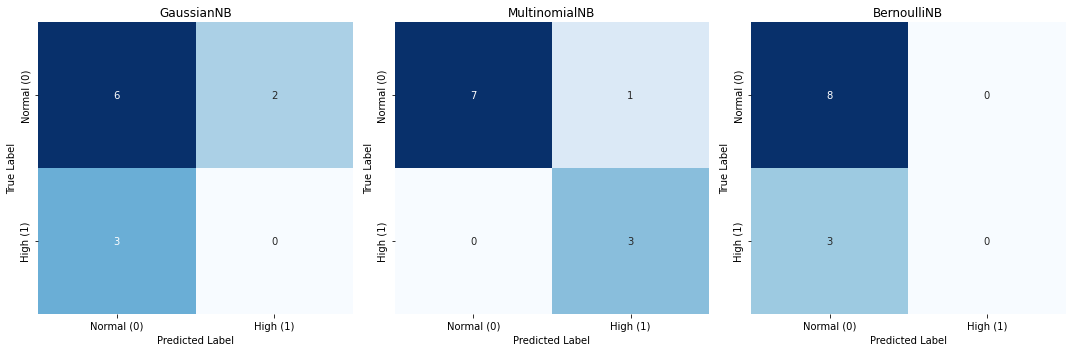

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['Normal (0)', 'High (1)'])
    ax.set_yticklabels(['Normal (0)', 'High (1)'])

plt.tight_layout()
plt.show()

### 11.	Plot and compare the ROC curves for GaussianNB, MultinomialNB, and BernoulliNB.

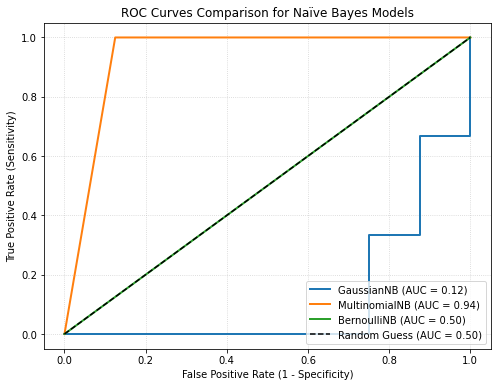

In [77]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves Comparison for Naïve Bayes Models')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 12.	Analyze the assumptions of each Naïve Bayes variant and determine which model is most suitable for the Cancer dataset

GaussianNB assumes continuous normal data, MultinomialNB expects discrete counts, and BernoulliNB requires binary inputs.
Empirically, MultinomialNB is the most suitable for this dataset, achieving top performance (ROC-AUC 0.9375) using count and rate features.